### LIBRARY IMPORTS

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import copy
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, accuracy_score
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier

if os.getcwd().endswith('notebooks'):
    os.chdir('..')

from src import *
from src.data_manager import DataManager
from src.processor import Processor
from src.nn_regressor import NNRegressor
from src.gb_classifier import GBClassifier

warnings.simplefilter(action='ignore', category=FutureWarning)

### CONFIGURATION

In [2]:
data_manager = DataManager()

datasets_config, modeling_config = data_manager.load_config()

active_dataset = modeling_config["main"]["active_dataset"]
active_dataset_config = datasets_config[active_dataset]
target = active_dataset_config["target"]

problem_type = active_dataset_config["problem_type"]

gradient_boosting_config = modeling_config["gradient_boosting"]

weak_learner_key = gradient_boosting_config["weak_learner_key"]
weak_learner_config = modeling_config[weak_learner_key]

processor = Processor(**active_dataset_config)

raw_train, raw_test = data_manager.load_raw_data()
raw_train = processor.cut_data(raw_train)

### STRATIFIED CROSS-VALIDATION

In [3]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def my_cross_validation(model, data, target, skf, processor):
    log_loss_scores = []
    accuracy_scores = []

    num_classes = len(np.unique(data[target]))
    oof_preds = np.zeros((len(data), num_classes), dtype=float)

    for train_idx, valid_idx in skf.split(data, data[target]):
        train_df = raw_train.iloc[train_idx]
        valid_df = raw_train.iloc[valid_idx]

        train_proc = processor.fit_transform(train_df)
        valid_proc = processor.transform(valid_df)

        X_train, y_train = train_proc.drop(columns=[target]), train_proc[target]
        X_valid, y_valid = valid_proc.drop(columns=[target]), valid_proc[target]

        model.fit(X_train, y_train)

        prob_preds = model.predict_proba(X_valid)
        class_preds = np.argmax(prob_preds, axis=1)
        
        oof_preds[valid_idx] = prob_preds

        fold_log_loss = log_loss(y_valid, prob_preds, labels=np.unique(y_train))
        fold_accuracy = accuracy_score(y_valid, class_preds)
        
        log_loss_scores.append(fold_log_loss)
        accuracy_scores.append(fold_accuracy)
    
    return log_loss_scores, accuracy_scores, oof_preds

### LOGISTIC REGRESSION

In [4]:
%%time

logistic = LogisticRegression(C=1.0, random_state=42)
logistic_log_loss_scores, logistic_accuracy_scores, logistic_oof_preds = my_cross_validation(logistic, raw_train, target, skf, processor)

CPU times: total: 2.48 s
Wall time: 1.37 s


In [5]:
print("Logistic regression log loss:", logistic_log_loss_scores)
print("Logistic regression accuracy:", logistic_accuracy_scores)

Logistic regression log loss: [0.2697083374586127, 0.2670589976179254, 0.2758899059085812, 0.27167092830671735, 0.2791858772055752]
Logistic regression accuracy: [0.8886, 0.89185, 0.88595, 0.88725, 0.88215]


### DECISION TREE

In [6]:
%%time

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_log_loss_scores, dt_accuracy_scores, dt_oof_preds = my_cross_validation(dt, raw_train, target, skf, processor)

CPU times: total: 1.48 s
Wall time: 1.48 s


In [7]:
print("Decision tree log loss:", dt_log_loss_scores)
print("Decision tree accuracy:", dt_accuracy_scores)

Decision tree log loss: [0.32993688135856475, 0.31909432879316635, 0.32635251177055696, 0.3247999491190048, 0.3335430533095905]
Decision tree accuracy: [0.85845, 0.86505, 0.8651, 0.86155, 0.85695]


### RANDOM FOREST

In [8]:
%%time

rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_log_loss_scores, rf_accuracy_scores, rf_oof_preds = my_cross_validation(rf, raw_train, target, skf, processor)

CPU times: total: 14 s
Wall time: 14 s


In [9]:
print("Random forest log loss:", rf_log_loss_scores)
print("Random forest accuracy:", rf_accuracy_scores)

Random forest log loss: [0.32126289442411876, 0.31435168984356093, 0.3192231125932434, 0.31609176277492995, 0.32313417347027207]
Random forest accuracy: [0.872, 0.87545, 0.87315, 0.8747, 0.8654]


### NEURAL NETWORK

In [10]:
class MLP(NNRegressor):
    def __init__(self, **hyperparameters):
        super().__init__(**hyperparameters)

    def fit(
        self,
        X: np.ndarray,
        y: np.ndarray,
    ) -> None:
        input_size = X.shape[1]
        unique_classes = np.unique(y)
        output_size = len(unique_classes)

        self._get_network(input_size, output_size)

        loader = self._prepare_loader(X, y)
        
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(self.parameters(), self.learning_rate)
        scheduler = torch.optim.lr_scheduler.OneCycleLR(
            optimizer, 
            max_lr=self.learning_rate, 
            steps_per_epoch=len(loader), 
            epochs=self.epochs
        )

        self.train()
        for _ in range(self.epochs):
            for batch_X, batch_y in loader:
                batch_X = batch_X.to(self.device)
                batch_y = batch_y.to(self.device)

                optimizer.zero_grad()
                
                preds = self(batch_X)
                loss = criterion(preds, batch_y.to(torch.long).to(self.device).squeeze())
                
                loss.backward()
                optimizer.step()
                scheduler.step()
    
    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        X_t = torch.from_numpy(X).to(torch.float32).to(self.device)
        self.eval()
        with torch.no_grad():
            logits = self.forward(X_t)
            predictions = torch.softmax(logits, dim=1)
        
        return predictions.cpu().numpy()

In [11]:
%%time

mlp = MLP(epochs=5, learning_rate=0.01, hidden_size=64, batch_size=1024)

mlp_log_loss_scores = []
mlp_accuracy_scores = []
num_classes = len(np.unique(raw_train[target]))
mlp_oof_preds = np.zeros((len(raw_train), num_classes), dtype=float)

for train_idx, valid_idx in skf.split(raw_train, raw_train[target]):
    train_df = raw_train.iloc[train_idx]
    valid_df = raw_train.iloc[valid_idx]

    train_proc = processor.fit_transform(train_df)
    valid_proc = processor.transform(valid_df)

    X_train, y_train = train_proc.drop(columns=[target]), train_proc[target]
    X_valid, y_valid = valid_proc.drop(columns=[target]), valid_proc[target]

    mlp.fit(X_train.values, y_train.values)

    prob_preds = mlp.predict_proba(X_valid.values)
    class_preds = np.argmax(prob_preds, axis=1)
    
    mlp_oof_preds[valid_idx] = prob_preds

    fold_log_loss = log_loss(y_valid, prob_preds, labels=np.unique(y_train))
    fold_accuracy = accuracy_score(y_valid, class_preds)

    mlp_log_loss_scores.append(fold_log_loss)
    mlp_accuracy_scores.append(fold_accuracy)

CPU times: total: 47.6 s
Wall time: 20.4 s


In [12]:
print("Neural network log loss:", mlp_log_loss_scores)
print("Neural network accuracy:", mlp_accuracy_scores)

Neural network log loss: [0.26963947520887716, 0.26725576311645366, 0.27540451804863597, 0.27117786886592665, 0.2790168646603959]
Neural network accuracy: [0.88905, 0.89105, 0.8866, 0.888, 0.88205]


### GRADIENT BOOSTING (DTs)

In [13]:
%%time

gb_log_loss_scores = []
gb_accuracy_scores = []
num_classes = len(np.unique(raw_train[target]))
gb_oof_preds = np.zeros((len(raw_train), num_classes), dtype=float)

for train_idx, valid_idx in skf.split(raw_train, raw_train[target]):
    train_df = raw_train.iloc[train_idx]
    valid_df = raw_train.iloc[valid_idx]

    train_proc = processor.fit_transform(train_df)
    valid_proc = processor.transform(valid_df)

    X_train, y_train = train_proc.drop(columns=[target]), train_proc[target]
    X_valid, y_valid = valid_proc.drop(columns=[target]), valid_proc[target]

    gb = GBClassifier(
        n_estimators=1000,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=0.1,
        early_stopping_rounds=10,
        weak_learner_key="decision_tree",
        weak_learner_config={"max_depth": 5, "random_state": 42}
    )
    
    gb.fit(X_train.values, y_train.values, X_valid.values, y_valid.values)

    prob_preds = gb.predict_proba(X_valid.values)
    class_preds = np.argmax(prob_preds, axis=1)
    
    gb_oof_preds[valid_idx] = prob_preds

    fold_log_loss = log_loss(y_valid, prob_preds, labels=np.unique(y_train))
    fold_accuracy = accuracy_score(y_valid, class_preds)
    
    gb_log_loss_scores.append(fold_log_loss)
    gb_accuracy_scores.append(fold_accuracy)
    
    print('-' * 50)

2026-04-26 14:00:02,727 - INFO - Iteration: 10 | Validation Log Loss: 0.356193 | Validation Accuracy: 0.877100
2026-04-26 14:00:04,063 - INFO - Iteration: 20 | Validation Log Loss: 0.301340 | Validation Accuracy: 0.883100
2026-04-26 14:00:05,392 - INFO - Iteration: 30 | Validation Log Loss: 0.283811 | Validation Accuracy: 0.885500
2026-04-26 14:00:06,724 - INFO - Iteration: 40 | Validation Log Loss: 0.276346 | Validation Accuracy: 0.887000
2026-04-26 14:00:08,137 - INFO - Iteration: 50 | Validation Log Loss: 0.272936 | Validation Accuracy: 0.888850
2026-04-26 14:00:09,482 - INFO - Iteration: 60 | Validation Log Loss: 0.271140 | Validation Accuracy: 0.890050
2026-04-26 14:00:10,822 - INFO - Iteration: 70 | Validation Log Loss: 0.270052 | Validation Accuracy: 0.890100
2026-04-26 14:00:12,132 - INFO - Iteration: 80 | Validation Log Loss: 0.269295 | Validation Accuracy: 0.889700
2026-04-26 14:00:13,452 - INFO - Iteration: 90 | Validation Log Loss: 0.268772 | Validation Accuracy: 0.890350
2

--------------------------------------------------


2026-04-26 14:00:26,401 - INFO - Iteration: 10 | Validation Log Loss: 0.352530 | Validation Accuracy: 0.881750
2026-04-26 14:00:27,707 - INFO - Iteration: 20 | Validation Log Loss: 0.296477 | Validation Accuracy: 0.887300
2026-04-26 14:00:29,058 - INFO - Iteration: 30 | Validation Log Loss: 0.279496 | Validation Accuracy: 0.890300
2026-04-26 14:00:30,415 - INFO - Iteration: 40 | Validation Log Loss: 0.272766 | Validation Accuracy: 0.891350
2026-04-26 14:00:31,709 - INFO - Iteration: 50 | Validation Log Loss: 0.269944 | Validation Accuracy: 0.892700
2026-04-26 14:00:33,021 - INFO - Iteration: 60 | Validation Log Loss: 0.268386 | Validation Accuracy: 0.892400
2026-04-26 14:00:34,347 - INFO - Iteration: 70 | Validation Log Loss: 0.267561 | Validation Accuracy: 0.893600
2026-04-26 14:00:35,702 - INFO - Iteration: 80 | Validation Log Loss: 0.267201 | Validation Accuracy: 0.892400
2026-04-26 14:00:37,016 - INFO - Iteration: 90 | Validation Log Loss: 0.266770 | Validation Accuracy: 0.892450
2

--------------------------------------------------


2026-04-26 14:00:46,048 - INFO - Iteration: 10 | Validation Log Loss: 0.356038 | Validation Accuracy: 0.878650
2026-04-26 14:00:47,385 - INFO - Iteration: 20 | Validation Log Loss: 0.302445 | Validation Accuracy: 0.883500
2026-04-26 14:00:48,729 - INFO - Iteration: 30 | Validation Log Loss: 0.286687 | Validation Accuracy: 0.884250
2026-04-26 14:00:49,994 - INFO - Iteration: 40 | Validation Log Loss: 0.281034 | Validation Accuracy: 0.885050
2026-04-26 14:00:51,314 - INFO - Iteration: 50 | Validation Log Loss: 0.278581 | Validation Accuracy: 0.885800
2026-04-26 14:00:52,614 - INFO - Iteration: 60 | Validation Log Loss: 0.277120 | Validation Accuracy: 0.885750
2026-04-26 14:00:53,936 - INFO - Iteration: 70 | Validation Log Loss: 0.276471 | Validation Accuracy: 0.885550
2026-04-26 14:00:55,253 - INFO - Iteration: 80 | Validation Log Loss: 0.275990 | Validation Accuracy: 0.885700
2026-04-26 14:00:56,609 - INFO - Iteration: 90 | Validation Log Loss: 0.275756 | Validation Accuracy: 0.885250
2

--------------------------------------------------


2026-04-26 14:01:05,312 - INFO - Iteration: 10 | Validation Log Loss: 0.354082 | Validation Accuracy: 0.880500
2026-04-26 14:01:06,661 - INFO - Iteration: 20 | Validation Log Loss: 0.299157 | Validation Accuracy: 0.885750
2026-04-26 14:01:07,958 - INFO - Iteration: 30 | Validation Log Loss: 0.282866 | Validation Accuracy: 0.887000
2026-04-26 14:01:09,261 - INFO - Iteration: 40 | Validation Log Loss: 0.276735 | Validation Accuracy: 0.887250
2026-04-26 14:01:10,541 - INFO - Iteration: 50 | Validation Log Loss: 0.273791 | Validation Accuracy: 0.888600
2026-04-26 14:01:11,822 - INFO - Iteration: 60 | Validation Log Loss: 0.272492 | Validation Accuracy: 0.888700
2026-04-26 14:01:13,126 - INFO - Iteration: 70 | Validation Log Loss: 0.271631 | Validation Accuracy: 0.888850
2026-04-26 14:01:14,418 - INFO - Iteration: 80 | Validation Log Loss: 0.271194 | Validation Accuracy: 0.888550
2026-04-26 14:01:15,763 - INFO - Iteration: 90 | Validation Log Loss: 0.270952 | Validation Accuracy: 0.888450
2

--------------------------------------------------


2026-04-26 14:01:22,165 - INFO - Iteration: 10 | Validation Log Loss: 0.360413 | Validation Accuracy: 0.872150
2026-04-26 14:01:23,464 - INFO - Iteration: 20 | Validation Log Loss: 0.305589 | Validation Accuracy: 0.879400
2026-04-26 14:01:24,754 - INFO - Iteration: 30 | Validation Log Loss: 0.289389 | Validation Accuracy: 0.882450
2026-04-26 14:01:26,057 - INFO - Iteration: 40 | Validation Log Loss: 0.283555 | Validation Accuracy: 0.882200
2026-04-26 14:01:27,410 - INFO - Iteration: 50 | Validation Log Loss: 0.280942 | Validation Accuracy: 0.883200
2026-04-26 14:01:28,751 - INFO - Iteration: 60 | Validation Log Loss: 0.279682 | Validation Accuracy: 0.883700
2026-04-26 14:01:30,055 - INFO - Iteration: 70 | Validation Log Loss: 0.279099 | Validation Accuracy: 0.883650
2026-04-26 14:01:31,334 - INFO - Iteration: 80 | Validation Log Loss: 0.278779 | Validation Accuracy: 0.883450
2026-04-26 14:01:32,679 - INFO - Iteration: 90 | Validation Log Loss: 0.278406 | Validation Accuracy: 0.883650
2

--------------------------------------------------
CPU times: total: 1min 37s
Wall time: 1min 37s


In [14]:
print("Gradient boosting (DTs) log loss:", gb_log_loss_scores)
print("Gradient boosting (DTs) accuracy:", gb_accuracy_scores)

Gradient boosting (DTs) log loss: [0.26672037945086174, 0.2657734738119109, 0.2751485885887789, 0.2704866933536679, 0.2776742769645743]
Gradient boosting (DTs) accuracy: [0.89235, 0.89275, 0.8865, 0.88835, 0.88375]


### XGBOOST

In [15]:
%%time

xgb_log_loss_scores = []
xgb_accuracy_scores = []
num_classes = len(np.unique(raw_train[target]))
xgb_oof_preds = np.zeros((len(raw_train), num_classes), dtype=float)

for train_idx, valid_idx in skf.split(raw_train, raw_train[target]):
    train_df = raw_train.iloc[train_idx]
    valid_df = raw_train.iloc[valid_idx]

    train_proc = processor.fit_transform(train_df)
    valid_proc = processor.transform(valid_df)

    X_train, y_train = train_proc.drop(columns=[target]), train_proc[target]
    X_valid, y_valid = valid_proc.drop(columns=[target]), valid_proc[target]

    xgb = XGBClassifier(
        n_estimators=1000,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=0.1,
        early_stopping_rounds=10,
        max_depth=5,
        random_state=42
    )
    
    xgb.fit(X_train.values, y_train.values, eval_set=[(X_valid.values, y_valid.values)], verbose=False)

    prob_preds = xgb.predict_proba(X_valid.values)
    class_preds = np.argmax(prob_preds, axis=1)
    
    xgb_oof_preds[valid_idx] = prob_preds

    fold_log_loss = log_loss(y_valid, prob_preds, labels=np.unique(y_train))
    fold_accuracy = accuracy_score(y_valid, class_preds)
    
    xgb_log_loss_scores.append(fold_log_loss)
    xgb_accuracy_scores.append(fold_accuracy)

CPU times: total: 36.7 s
Wall time: 3.52 s


In [16]:
print("XGBoost log loss:", xgb_log_loss_scores)
print("XGBoost accuracy:", xgb_accuracy_scores)

XGBoost log loss: [0.26566731695810797, 0.2655771497323062, 0.272687098226783, 0.2674643077992885, 0.27633285708658506]
XGBoost accuracy: [0.8913, 0.8926, 0.88785, 0.88945, 0.8831]


### GRADIENT BOOSTING (NNs)

In [17]:
%%time

nn_gb_log_loss_scores = []
nn_gb_accuracy_scores = []
num_classes = len(np.unique(raw_train[target]))
nn_gb_oof_preds = np.zeros((len(raw_train), num_classes), dtype=float)

for train_idx, valid_idx in skf.split(raw_train, raw_train[target]):
    train_df = raw_train.iloc[train_idx]
    valid_df = raw_train.iloc[valid_idx]

    train_proc = processor.fit_transform(train_df)
    valid_proc = processor.transform(valid_df)

    X_train, y_train = train_proc.drop(columns=[target]), train_proc[target]
    X_valid, y_valid = valid_proc.drop(columns=[target]), valid_proc[target]

    nn_gb = GBClassifier(
        n_estimators=1000,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=0.1,
        early_stopping_rounds=10,
        weak_learner_key="neural_network",
        weak_learner_config={
            "epochs": 5,
            "learning_rate": 0.01,
            "hidden_size": 64,
            "batch_size": 1024
        }
    )
    
    nn_gb.fit(X_train.values, y_train.values, X_valid.values, y_valid.values)

    prob_preds = nn_gb.predict_proba(X_valid.values)
    class_preds = np.argmax(prob_preds, axis=1)
    
    nn_gb_oof_preds[valid_idx] = prob_preds

    fold_log_loss = log_loss(y_valid, prob_preds, labels=np.unique(y_train))
    fold_accuracy = accuracy_score(y_valid, class_preds)
    
    nn_gb_log_loss_scores.append(fold_log_loss)
    nn_gb_accuracy_scores.append(fold_accuracy)
    
    print('-' * 50)

2026-04-26 14:02:10,129 - INFO - Iteration: 10 | Validation Log Loss: 0.337650 | Validation Accuracy: 0.888000
2026-04-26 14:02:38,047 - INFO - Iteration: 20 | Validation Log Loss: 0.290816 | Validation Accuracy: 0.887150
2026-04-26 14:03:05,848 - INFO - Iteration: 30 | Validation Log Loss: 0.278561 | Validation Accuracy: 0.888150
2026-04-26 14:03:33,668 - INFO - Iteration: 40 | Validation Log Loss: 0.274412 | Validation Accuracy: 0.888250
2026-04-26 14:04:01,536 - INFO - Iteration: 50 | Validation Log Loss: 0.272689 | Validation Accuracy: 0.888850
2026-04-26 14:04:29,442 - INFO - Iteration: 60 | Validation Log Loss: 0.271833 | Validation Accuracy: 0.888900
2026-04-26 14:04:57,294 - INFO - Iteration: 70 | Validation Log Loss: 0.271332 | Validation Accuracy: 0.889250
2026-04-26 14:05:25,140 - INFO - Iteration: 80 | Validation Log Loss: 0.270980 | Validation Accuracy: 0.889450
2026-04-26 14:05:52,917 - INFO - Iteration: 90 | Validation Log Loss: 0.270746 | Validation Accuracy: 0.889450
2

--------------------------------------------------


2026-04-26 14:14:12,845 - INFO - Iteration: 10 | Validation Log Loss: 0.335873 | Validation Accuracy: 0.889950
2026-04-26 14:14:40,744 - INFO - Iteration: 20 | Validation Log Loss: 0.286831 | Validation Accuracy: 0.890400
2026-04-26 14:15:08,679 - INFO - Iteration: 30 | Validation Log Loss: 0.275181 | Validation Accuracy: 0.890350
2026-04-26 14:15:36,544 - INFO - Iteration: 40 | Validation Log Loss: 0.271385 | Validation Accuracy: 0.890600
2026-04-26 14:16:04,325 - INFO - Iteration: 50 | Validation Log Loss: 0.269732 | Validation Accuracy: 0.890700
2026-04-26 14:16:32,062 - INFO - Iteration: 60 | Validation Log Loss: 0.268990 | Validation Accuracy: 0.890550
2026-04-26 14:16:59,700 - INFO - Iteration: 70 | Validation Log Loss: 0.268552 | Validation Accuracy: 0.890600
2026-04-26 14:17:27,656 - INFO - Iteration: 80 | Validation Log Loss: 0.268285 | Validation Accuracy: 0.890250
2026-04-26 14:17:55,587 - INFO - Iteration: 90 | Validation Log Loss: 0.268144 | Validation Accuracy: 0.890050
2

--------------------------------------------------


2026-04-26 14:21:25,351 - INFO - Iteration: 10 | Validation Log Loss: 0.340423 | Validation Accuracy: 0.884800
2026-04-26 14:21:53,690 - INFO - Iteration: 20 | Validation Log Loss: 0.293411 | Validation Accuracy: 0.886350
2026-04-26 14:22:22,013 - INFO - Iteration: 30 | Validation Log Loss: 0.282560 | Validation Accuracy: 0.886600
2026-04-26 14:22:49,880 - INFO - Iteration: 40 | Validation Log Loss: 0.279145 | Validation Accuracy: 0.887400
2026-04-26 14:23:17,767 - INFO - Iteration: 50 | Validation Log Loss: 0.277975 | Validation Accuracy: 0.887200
2026-04-26 14:23:45,571 - INFO - Iteration: 60 | Validation Log Loss: 0.277370 | Validation Accuracy: 0.887450
2026-04-26 14:24:13,541 - INFO - Iteration: 70 | Validation Log Loss: 0.277077 | Validation Accuracy: 0.887400
2026-04-26 14:24:41,508 - INFO - Iteration: 80 | Validation Log Loss: 0.276873 | Validation Accuracy: 0.887300
2026-04-26 14:25:09,457 - INFO - Iteration: 90 | Validation Log Loss: 0.276686 | Validation Accuracy: 0.886800
2

--------------------------------------------------


2026-04-26 14:30:21,542 - INFO - Iteration: 10 | Validation Log Loss: 0.337425 | Validation Accuracy: 0.887350
2026-04-26 14:30:49,121 - INFO - Iteration: 20 | Validation Log Loss: 0.289180 | Validation Accuracy: 0.886700
2026-04-26 14:31:16,886 - INFO - Iteration: 30 | Validation Log Loss: 0.278087 | Validation Accuracy: 0.887150
2026-04-26 14:31:44,662 - INFO - Iteration: 40 | Validation Log Loss: 0.274618 | Validation Accuracy: 0.887600
2026-04-26 14:32:12,231 - INFO - Iteration: 50 | Validation Log Loss: 0.273246 | Validation Accuracy: 0.887800
2026-04-26 14:32:39,979 - INFO - Iteration: 60 | Validation Log Loss: 0.272562 | Validation Accuracy: 0.887750
2026-04-26 14:33:07,587 - INFO - Iteration: 70 | Validation Log Loss: 0.272203 | Validation Accuracy: 0.887750
2026-04-26 14:33:35,178 - INFO - Iteration: 80 | Validation Log Loss: 0.272027 | Validation Accuracy: 0.888300
2026-04-26 14:34:02,901 - INFO - Iteration: 90 | Validation Log Loss: 0.271899 | Validation Accuracy: 0.888350
2

--------------------------------------------------


2026-04-26 14:38:48,984 - INFO - Iteration: 10 | Validation Log Loss: 0.345122 | Validation Accuracy: 0.879550
2026-04-26 14:39:16,845 - INFO - Iteration: 20 | Validation Log Loss: 0.298010 | Validation Accuracy: 0.880700
2026-04-26 14:39:44,770 - INFO - Iteration: 30 | Validation Log Loss: 0.286694 | Validation Accuracy: 0.881150
2026-04-26 14:40:12,502 - INFO - Iteration: 40 | Validation Log Loss: 0.282946 | Validation Accuracy: 0.881350
2026-04-26 14:40:40,240 - INFO - Iteration: 50 | Validation Log Loss: 0.281661 | Validation Accuracy: 0.881500
2026-04-26 14:41:07,912 - INFO - Iteration: 60 | Validation Log Loss: 0.280996 | Validation Accuracy: 0.881950
2026-04-26 14:41:35,588 - INFO - Iteration: 70 | Validation Log Loss: 0.280669 | Validation Accuracy: 0.882250
2026-04-26 14:42:03,464 - INFO - Iteration: 80 | Validation Log Loss: 0.280497 | Validation Accuracy: 0.882150
2026-04-26 14:42:31,213 - INFO - Iteration: 90 | Validation Log Loss: 0.280356 | Validation Accuracy: 0.882000
2

--------------------------------------------------
CPU times: total: 2h 7min 19s
Wall time: 43min 11s


In [18]:
print("NN GB log loss:", nn_gb_log_loss_scores)
print("NN GB accuracy:", nn_gb_accuracy_scores)

NN GB log loss: [0.2699689356214056, 0.2678788307011292, 0.2762599926962644, 0.27162888121485324, 0.2800435935270909]
NN GB accuracy: [0.88885, 0.8903, 0.8867, 0.8883, 0.88145]


### VISUALIZATION (BY MEAN)

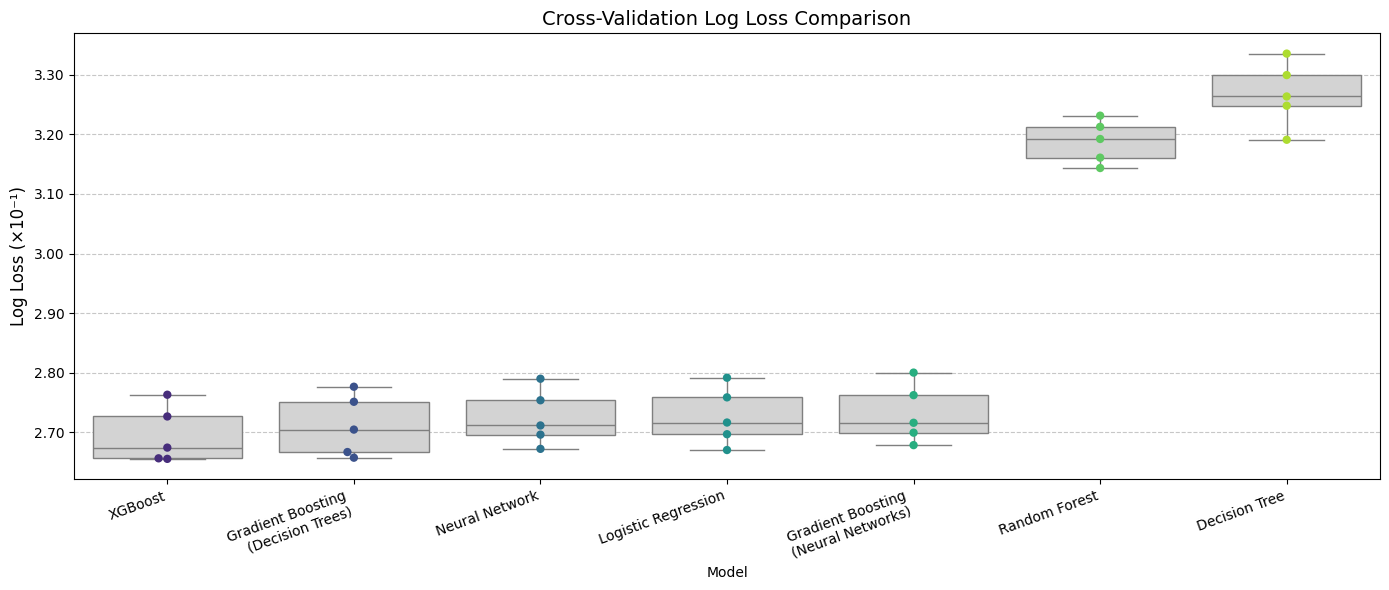

In [19]:
# 1. Prepare data
results_df = pd.DataFrame({
    'Logistic Regression': logistic_log_loss_scores,
    'Decision Tree': dt_log_loss_scores,
    'Random Forest': rf_log_loss_scores,
    'Neural Network': mlp_log_loss_scores,
    "GB (Decision Trees)": gb_log_loss_scores,
    'XGBoost': xgb_log_loss_scores,
    'GB (Neural Networks)': nn_gb_log_loss_scores
})

melted_df = results_df.melt(var_name='Model', value_name='Log Loss')

# 2. Rename with clean multi-line labels
melted_df['Model'] = melted_df['Model'].replace({
    "GB (Decision Trees)": "Gradient Boosting\n(Decision Trees)",
    "GB (Neural Networks)": "Gradient Boosting\n(Neural Networks)"
})

# 3. Order models by mean Log Loss (best → worst)
model_order = (
    melted_df.groupby('Model')['Log Loss']
    .mean()
    .sort_values()
    .index
)

# 4. Plot
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=melted_df,
    x='Model',
    y='Log Loss',
    order=model_order,
    color='lightgray',
    showfliers=False
)

sns.swarmplot(
    data=melted_df,
    x='Model',
    y='Log Loss',
    order=model_order,
    palette='viridis',
    size=6
)

# 5. Y-axis in 10^-1 scale
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x*1e1:.2f}'))
plt.ylabel('Log Loss (×10⁻¹)', fontsize=12)

# 6. Clean styling
plt.xticks(rotation=20, ha='right')
plt.title('Cross-Validation Log Loss Comparison', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

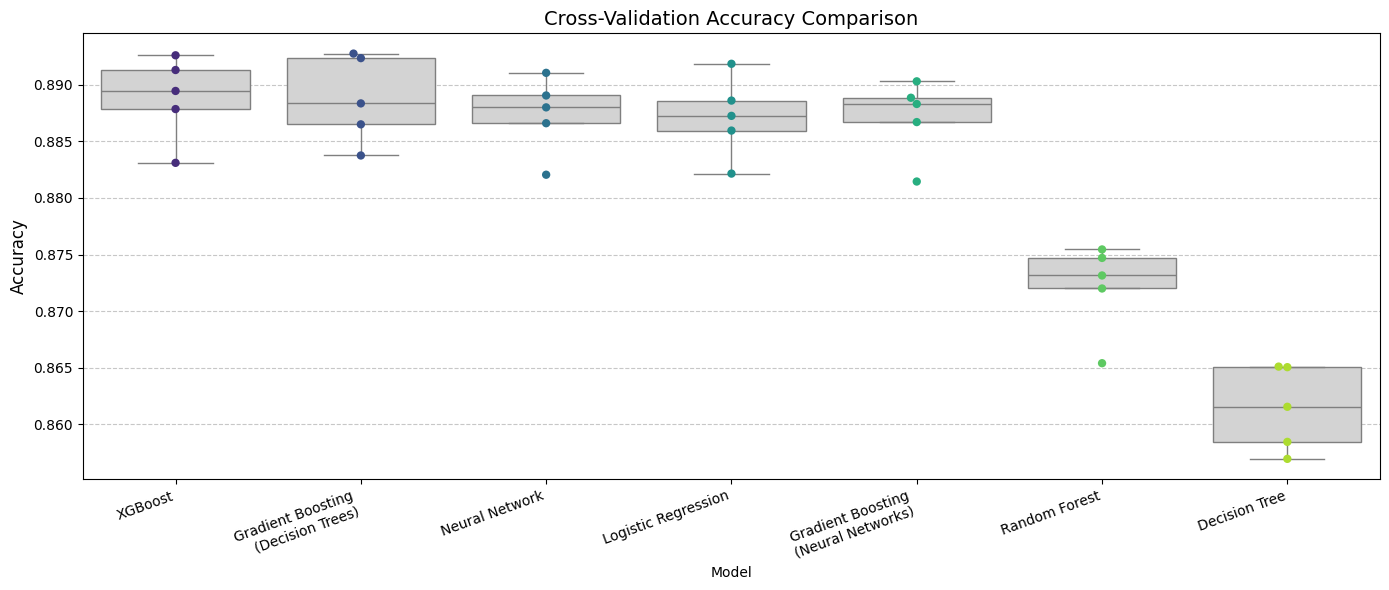

In [20]:
# 1. Prepare data
results_df = pd.DataFrame({
    'Logistic Regression': logistic_accuracy_scores,
    'Decision Tree': dt_accuracy_scores,
    'Random Forest': rf_accuracy_scores,
    'Neural Network': mlp_accuracy_scores,
    "GB (Decision Trees)": gb_accuracy_scores,
    'XGBoost': xgb_accuracy_scores,
    'GB (Neural Networks)': nn_gb_accuracy_scores
})

melted_df = results_df.melt(var_name='Model', value_name='Accuracy')

# 2. Rename with clean multi-line labels
melted_df['Model'] = melted_df['Model'].replace({
    "GB (Decision Trees)": "Gradient Boosting\n(Decision Trees)",
    "GB (Neural Networks)": "Gradient Boosting\n(Neural Networks)"
})

# 3. Order models by mean Accuracy (best [max] → worst [min])
model_order = (
    melted_df.groupby('Model')['Accuracy']
    .mean()
    .sort_values(ascending=False)
    .index
)

# 4. Plot
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=melted_df,
    x='Model',
    y='Accuracy',
    order=model_order,
    color='lightgray',
    showfliers=False
)

sns.swarmplot(
    data=melted_df,
    x='Model',
    y='Accuracy',
    order=model_order,
    palette='viridis',
    size=6
)

# 5. Y-axis - No scaling
plt.ylabel('Accuracy', fontsize=12)

# 6. Clean styling
plt.xticks(rotation=20, ha='right')
plt.title('Cross-Validation Accuracy Comparison', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### VISUALIZATION (BY MEDIAN)

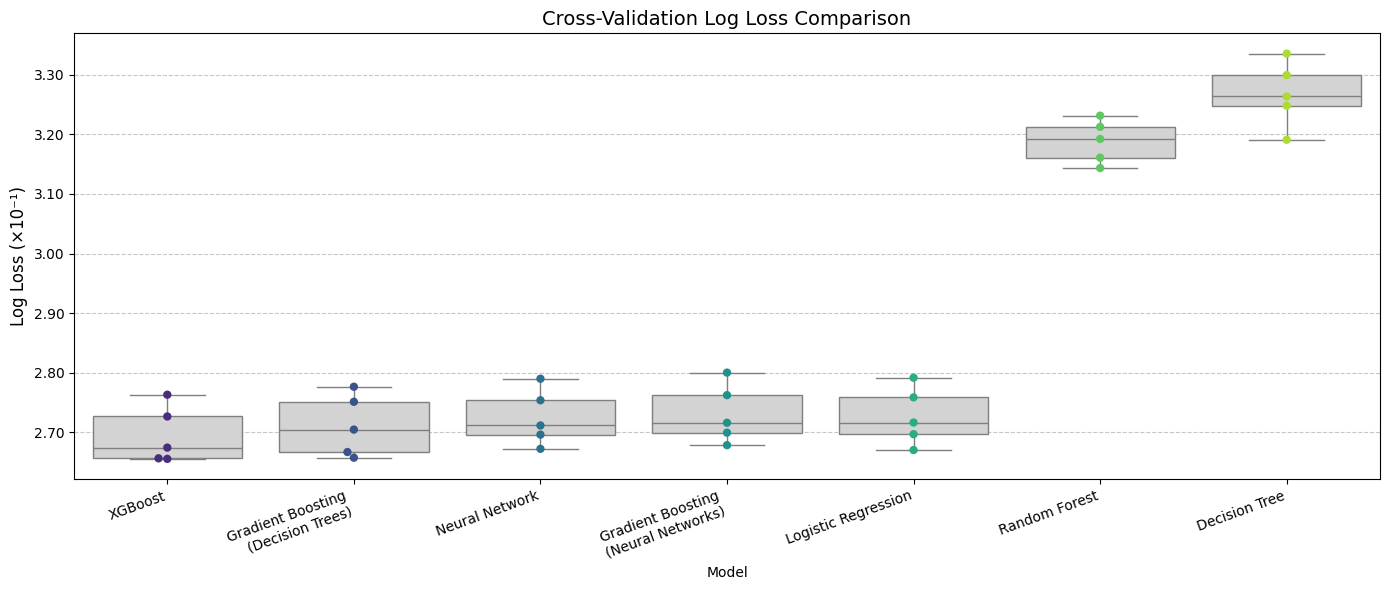

In [21]:
# 1. Prepare data
results_df = pd.DataFrame({
    'Logistic Regression': logistic_log_loss_scores,
    'Decision Tree': dt_log_loss_scores,
    'Random Forest': rf_log_loss_scores,
    'Neural Network': mlp_log_loss_scores,
    "GB (Decision Trees)": gb_log_loss_scores,
    'XGBoost': xgb_log_loss_scores,
    'GB (Neural Networks)': nn_gb_log_loss_scores
})

melted_df = results_df.melt(var_name='Model', value_name='Log Loss')

# 2. Rename with clean multi-line labels
melted_df['Model'] = melted_df['Model'].replace({
    "GB (Decision Trees)": "Gradient Boosting\n(Decision Trees)",
    "GB (Neural Networks)": "Gradient Boosting\n(Neural Networks)"
})

# 3. Order models by mean Log Loss (best → worst)
model_order = (
    melted_df.groupby('Model')['Log Loss']
    .median()
    .sort_values()
    .index
)

# 4. Plot
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=melted_df,
    x='Model',
    y='Log Loss',
    order=model_order,
    color='lightgray',
    showfliers=False
)

sns.swarmplot(
    data=melted_df,
    x='Model',
    y='Log Loss',
    order=model_order,
    palette='viridis',
    size=6
)

# 5. Y-axis in 10^-1 scale
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x*1e1:.2f}'))
plt.ylabel('Log Loss (×10⁻¹)', fontsize=12)

# 6. Clean styling
plt.xticks(rotation=20, ha='right')
plt.title('Cross-Validation Log Loss Comparison', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

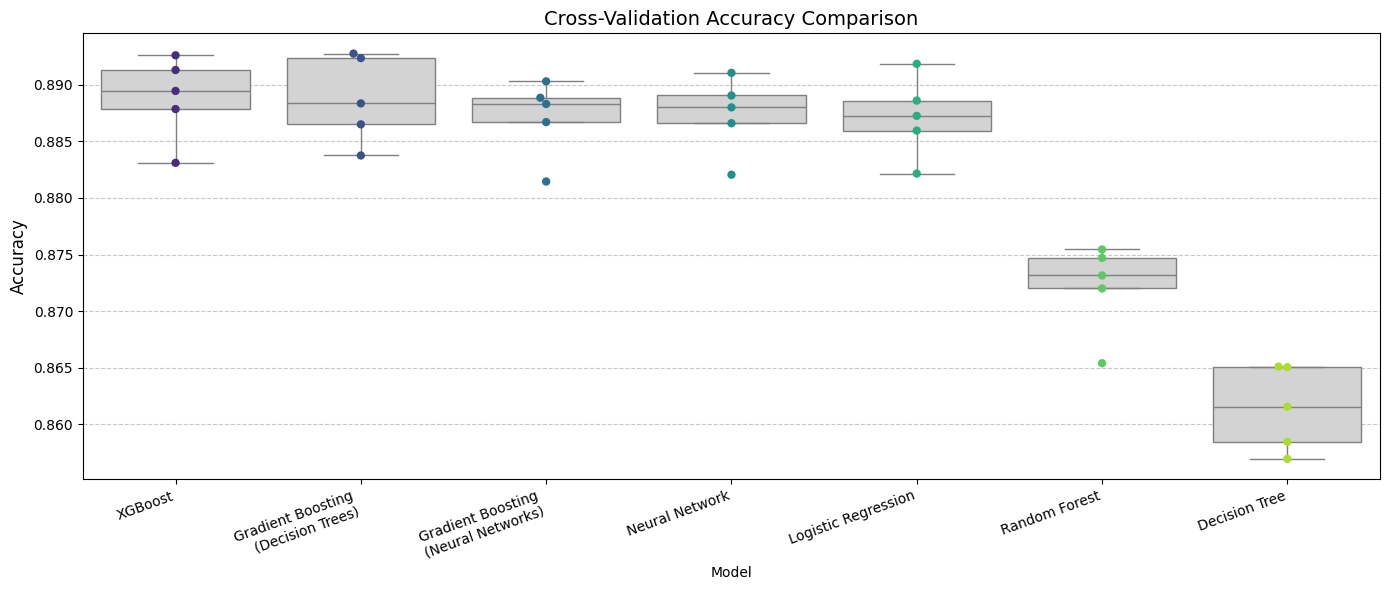

In [22]:
# 1. Prepare data
results_df = pd.DataFrame({
    'Logistic Regression': logistic_accuracy_scores,
    'Decision Tree': dt_accuracy_scores,
    'Random Forest': rf_accuracy_scores,
    'Neural Network': mlp_accuracy_scores,
    "GB (Decision Trees)": gb_accuracy_scores,
    'XGBoost': xgb_accuracy_scores,
    'GB (Neural Networks)': nn_gb_accuracy_scores
})

melted_df = results_df.melt(var_name='Model', value_name='Accuracy')

# 2. Rename with clean multi-line labels
melted_df['Model'] = melted_df['Model'].replace({
    "GB (Decision Trees)": "Gradient Boosting\n(Decision Trees)",
    "GB (Neural Networks)": "Gradient Boosting\n(Neural Networks)"
})

# 3. Order models by mean Accuracy (best [max] → worst [min])
model_order = (
    melted_df.groupby('Model')['Accuracy']
    .median()
    .sort_values(ascending=False)
    .index
)

# 4. Plot
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=melted_df,
    x='Model',
    y='Accuracy',
    order=model_order,
    color='lightgray',
    showfliers=False
)

sns.swarmplot(
    data=melted_df,
    x='Model',
    y='Accuracy',
    order=model_order,
    palette='viridis',
    size=6
)

# 5. Y-axis - No scaling
plt.ylabel('Accuracy', fontsize=12)

# 6. Clean styling
plt.xticks(rotation=20, ha='right')
plt.title('Cross-Validation Accuracy Comparison', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()